[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/14_busqueda_informada/notebooks/aplicaciones/03_rutas.ipynb)

# Notebook 03: Rutas en una Ciudad — Dijkstra vs A*

En este notebook exploraremos el problema de encontrar rutas óptimas en un grafo sintético de ciudad con **15 nodos**. Compararemos dos algoritmos clásicos de búsqueda informada:

- **Dijkstra**: encuentra el camino más corto desde un origen a todos los demás nodos, sin usar información del destino.
- **A\***: usa una heurística (distancia en línea recta) para guiar la búsqueda de manera más eficiente hacia el destino.

Al finalizar podrás:
1. Construir grafos ponderados y visualizarlos con NetworkX.
2. Implementar Dijkstra y A* desde cero.
3. Comparar el número de nodos expandidos por cada algoritmo.
4. Experimentar con heurísticas alternativas y analizar admisibilidad.

In [1]:
# Instalar dependencias si es necesario (Colab)
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

ensure("networkx")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import networkx as nx
import math
from collections import defaultdict

print("Dependencias listas.")

Dependencias listas.


In [2]:
# ── Estilo y colores ──────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "primary":    "#2563EB",
    "secondary":  "#10B981",
    "accent":     "#F59E0B",
    "danger":     "#EF4444",
    "node":       "#93C5FD",
    "edge":       "#475569",
}

plt.rcParams.update({
    "figure.dpi":       120,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "font.size":        10,
    "legend.fontsize":  9,
})

np.random.seed(42)
print("Estilo configurado.")

Estilo configurado.


---
## Sección 1: El Grafo de la Ciudad

Construiremos un grafo que representa una ciudad sintética con 15 ubicaciones clave. Cada nodo tiene coordenadas $(x, y)$ que usaremos tanto para visualización como para calcular la heurística de distancia en línea recta en A*.

Los pesos de las aristas representan el **costo de viaje** (tiempo o distancia) entre ubicaciones conectadas.

In [3]:
# ── Definición del grafo de la ciudad ────────────────────────────────────────

# Nodos con coordenadas (x, y) — escala arbitraria tipo km
POSICIONES = {
    "Centro":      (5.0, 5.0),
    "Aeropuerto":  (9.5, 8.5),
    "Universidad": (2.0, 8.0),
    "Hospital":    (4.0, 7.0),
    "Estadio":     (8.0, 3.0),
    "Mercado":     (3.5, 3.5),
    "Parque":      (6.5, 6.5),
    "Biblioteca":  (1.5, 5.5),
    "Teatro":      (5.5, 7.5),
    "Estacion":    (7.0, 5.0),
    "Plaza":       (5.0, 2.5),
    "Museo":       (2.5, 6.5),
    "Puerto":      (9.0, 1.5),
    "Fabrica":     (7.5, 7.5),
    "Residencial": (1.0, 2.0),
}

def dist_euclid(a, b):
    """Distancia euclidiana entre dos nodos por nombre."""
    xa, ya = POSICIONES[a]
    xb, yb = POSICIONES[b]
    return math.sqrt((xa - xb)**2 + (ya - yb)**2)

def peso(a, b, variacion=0.0):
    """Peso de arista = dist euclidiana + variacion aleatoria fija."""
    base = dist_euclid(a, b)
    return round(base + variacion, 2)

# Lista de aristas (nodo_a, nodo_b, peso)
ARISTAS_RAW = [
    ("Centro",      "Hospital",    peso("Centro",      "Hospital",    0.3)),
    ("Centro",      "Mercado",     peso("Centro",      "Mercado",     0.2)),
    ("Centro",      "Parque",      peso("Centro",      "Parque",      0.1)),
    ("Centro",      "Estacion",    peso("Centro",      "Estacion",    0.4)),
    ("Centro",      "Plaza",       peso("Centro",      "Plaza",       0.2)),
    ("Centro",      "Teatro",      peso("Centro",      "Teatro",      0.3)),
    ("Aeropuerto",  "Fabrica",     peso("Aeropuerto",  "Fabrica",     0.1)),
    ("Aeropuerto",  "Parque",      peso("Aeropuerto",  "Parque",      0.5)),
    ("Aeropuerto",  "Estacion",    peso("Aeropuerto",  "Estacion",    0.3)),
    ("Universidad", "Hospital",    peso("Universidad", "Hospital",    0.2)),
    ("Universidad", "Biblioteca",  peso("Universidad", "Biblioteca",  0.1)),
    ("Universidad", "Museo",       peso("Universidad", "Museo",       0.3)),
    ("Hospital",    "Teatro",      peso("Hospital",    "Teatro",      0.2)),
    ("Hospital",    "Museo",       peso("Hospital",    "Museo",       0.4)),
    ("Estadio",     "Puerto",      peso("Estadio",     "Puerto",      0.6)),
    ("Estadio",     "Estacion",    peso("Estadio",     "Estacion",    0.2)),
    ("Estadio",     "Plaza",       peso("Estadio",     "Plaza",       0.3)),
    ("Mercado",     "Plaza",       peso("Mercado",     "Plaza",       0.1)),
    ("Mercado",     "Residencial", peso("Mercado",     "Residencial", 0.4)),
    ("Mercado",     "Biblioteca",  peso("Mercado",     "Biblioteca",  0.5)),
    ("Parque",      "Teatro",      peso("Parque",      "Teatro",      0.1)),
    ("Parque",      "Fabrica",     peso("Parque",      "Fabrica",     0.2)),
    ("Biblioteca",  "Residencial", peso("Biblioteca",  "Residencial", 0.3)),
    ("Biblioteca",  "Museo",       peso("Biblioteca",  "Museo",       0.2)),
    ("Estacion",    "Fabrica",     peso("Estacion",    "Fabrica",     0.3)),
    ("Puerto",      "Fabrica",     peso("Puerto",      "Fabrica",     0.8)),
    ("Plaza",       "Residencial", peso("Plaza",       "Residencial", 0.5)),
]

# Construir el grafo como diccionario de adyacencia
GRAFO = defaultdict(dict)
for u, v, w in ARISTAS_RAW:
    GRAFO[u][v] = w
    GRAFO[v][u] = w

NODOS = list(POSICIONES.keys())
print(f"Nodos: {len(NODOS)}")
print(f"Aristas: {len(ARISTAS_RAW)}")
print("\nVecinos del Centro:", dict(GRAFO["Centro"]))

Nodos: 15
Aristas: 27

Vecinos del Centro: {'Hospital': 2.54, 'Mercado': 2.32, 'Parque': 2.22, 'Estacion': 2.4, 'Plaza': 2.7, 'Teatro': 2.85}


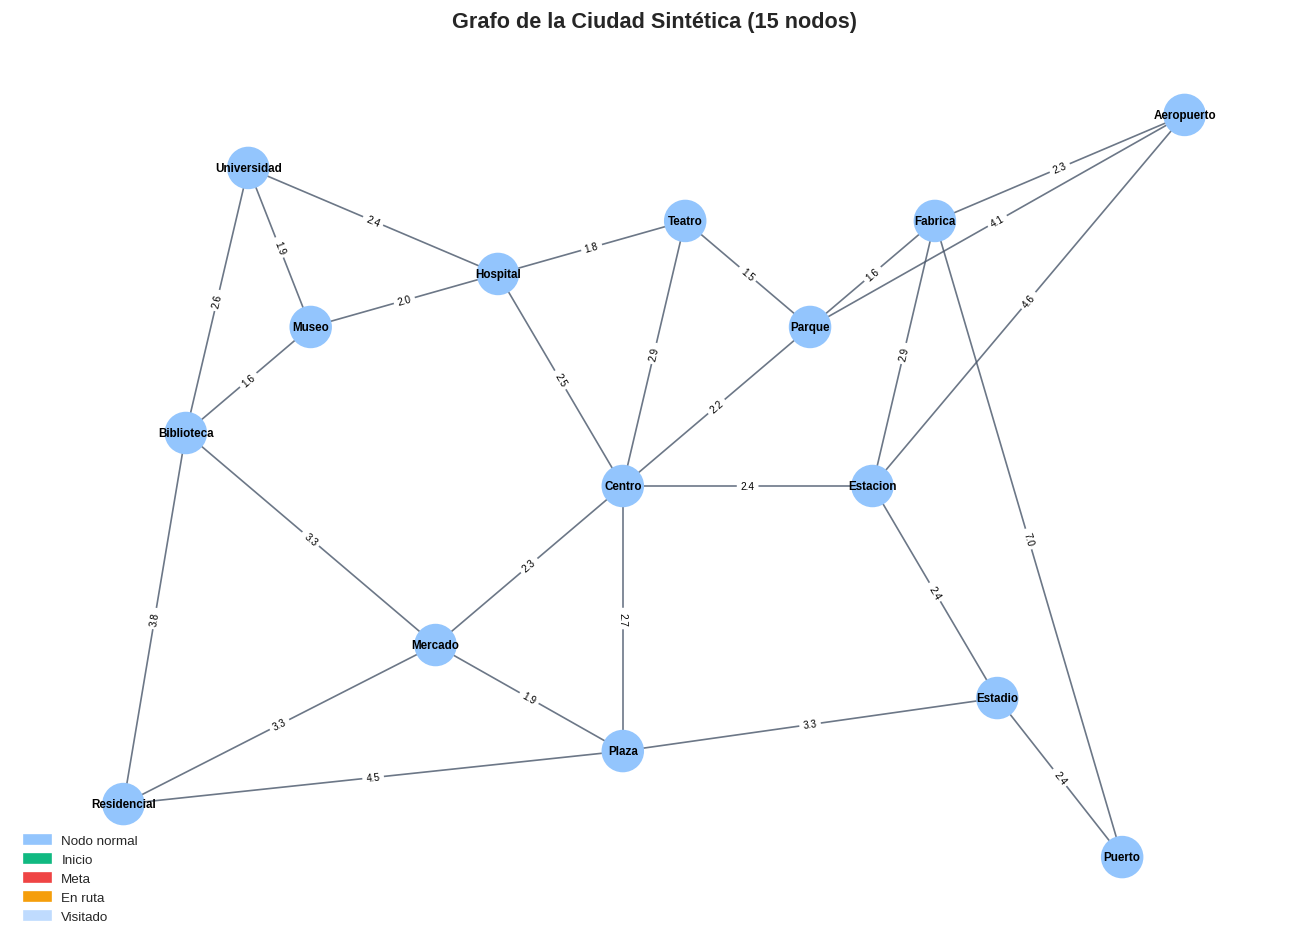


Grafo conexo: True


In [4]:
# ── Visualización del grafo completo ─────────────────────────────────────────

def construir_nx_grafo(aristas=None):
    """Construye un grafo NetworkX a partir de ARISTAS_RAW o aristas personalizadas."""
    G = nx.Graph()
    G.add_nodes_from(NODOS)
    for u, v, w in (aristas or ARISTAS_RAW):
        G.add_edge(u, v, weight=w)
    return G

def visualizar_grafo(G, titulo="Grafo de la Ciudad",
                     nodos_visitados=None, ruta=None,
                     inicio=None, meta=None,
                     aristas_resaltadas=None, ax=None):
    """
    Visualiza el grafo con opciones para resaltar rutas y nodos visitados.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 8))
    else:
        fig = ax.figure

    pos = POSICIONES

    # Colores de nodos
    color_nodos = []
    for n in G.nodes():
        if n == inicio:
            color_nodos.append(COLORS["secondary"])
        elif n == meta:
            color_nodos.append(COLORS["danger"])
        elif ruta and n in ruta:
            color_nodos.append(COLORS["accent"])
        elif nodos_visitados and n in nodos_visitados:
            color_nodos.append("#BFDBFE")  # azul claro
        else:
            color_nodos.append(COLORS["node"])

    # Aristas
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        if aristas_resaltadas and ((u, v) in aristas_resaltadas or (v, u) in aristas_resaltadas):
            edge_colors.append(COLORS["accent"])
            edge_widths.append(3.5)
        elif ruta and len(ruta) > 1:
            pares_ruta = set(zip(ruta, ruta[1:]))
            if (u, v) in pares_ruta or (v, u) in pares_ruta:
                edge_colors.append(COLORS["primary"])
                edge_widths.append(3.5)
            else:
                edge_colors.append(COLORS["edge"])
                edge_widths.append(1.0)
        else:
            edge_colors.append(COLORS["edge"])
            edge_widths.append(1.0)

    nx.draw_networkx_nodes(G, pos, node_color=color_nodos,
                           node_size=600, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors,
                           width=edge_widths, alpha=0.8, ax=ax)

    pesos_labels = nx.get_edge_attributes(G, "weight")
    pesos_str = {k: f"{v:.1f}" for k, v in pesos_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=pesos_str,
                                  font_size=6, ax=ax)

    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.axis("off")

    # Leyenda
    leyenda = [
        mpatches.Patch(color=COLORS["node"],      label="Nodo normal"),
        mpatches.Patch(color=COLORS["secondary"],  label="Inicio"),
        mpatches.Patch(color=COLORS["danger"],     label="Meta"),
        mpatches.Patch(color=COLORS["accent"],     label="En ruta"),
        mpatches.Patch(color="#BFDBFE",            label="Visitado"),
    ]
    ax.legend(handles=leyenda, loc="lower left", fontsize=8)
    return fig, ax

G_ciudad = construir_nx_grafo()
fig, ax = visualizar_grafo(G_ciudad, titulo="Grafo de la Ciudad Sintética (15 nodos)")
plt.tight_layout()
plt.show()
print(f"\nGrafo conexo: {nx.is_connected(G_ciudad)}")

---
## Sección 2: Dijkstra — Rutas Mínimas desde el Centro

El algoritmo de Dijkstra encuentra el **camino más corto** desde un nodo origen a **todos los demás nodos** del grafo. Opera de forma greedy: siempre expande el nodo con menor costo acumulado.

**Complejidad:** $O((V + E) \log V)$ con heap binario.

**Limitación:** No usa información del destino, por lo que explora en todas las direcciones.

In [5]:
# ── Implementación de Dijkstra ────────────────────────────────────────────────

def dijkstra(grafo, inicio):
    """
    Dijkstra desde `inicio` hacia todos los nodos.

    Retorna:
      distancias : dict nodo -> costo mínimo
      previos    : dict nodo -> nodo anterior en el camino óptimo
      expandidos : list de nodos en orden de expansión
    """
    distancias = {n: float('inf') for n in grafo}
    distancias[inicio] = 0.0
    previos = {n: None for n in grafo}
    expandidos = []

    # heap: (costo, nodo)
    heap = [(0.0, inicio)]

    visitados = set()

    while heap:
        costo, nodo = heapq.heappop(heap)

        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos.append(nodo)

        for vecino, peso in grafo[nodo].items():
            nuevo_costo = costo + peso
            if nuevo_costo < distancias[vecino]:
                distancias[vecino] = nuevo_costo
                previos[vecino] = nodo
                heapq.heappush(heap, (nuevo_costo, vecino))

    return distancias, previos, expandidos


def reconstruir_camino(previos, origen, destino):
    """Reconstruye el camino óptimo usando el diccionario de previos."""
    camino = []
    nodo = destino
    while nodo is not None:
        camino.append(nodo)
        nodo = previos.get(nodo)
    camino.reverse()
    if camino[0] != origen:
        return []  # no hay camino
    return camino


# Ejecutar Dijkstra desde el Centro
dist_centro, prev_centro, exp_centro = dijkstra(GRAFO, "Centro")

print("Dijkstra ejecutado desde: Centro")
print(f"Nodos expandidos: {len(exp_centro)}")
print(f"Orden de expansión: {exp_centro}")

Dijkstra ejecutado desde: Centro
Nodos expandidos: 15
Orden de expansión: ['Centro', 'Parque', 'Mercado', 'Estacion', 'Hospital', 'Plaza', 'Teatro', 'Fabrica', 'Museo', 'Estadio', 'Universidad', 'Residencial', 'Biblioteca', 'Aeropuerto', 'Puerto']


In [6]:
# ── Tabla de distancias desde el Centro ──────────────────────────────────────

print(f"{'Destino':<15} {'Distancia':>12}  Camino")
print("-" * 60)
for nodo in sorted(dist_centro, key=lambda n: dist_centro[n]):
    if nodo == "Centro":
        continue
    camino = reconstruir_camino(prev_centro, "Centro", nodo)
    camino_str = " → ".join(camino)
    print(f"{nodo:<15} {dist_centro[nodo]:>12.2f}  {camino_str}")

Destino            Distancia  Camino
------------------------------------------------------------
Parque                  2.22  Centro → Parque
Mercado                 2.32  Centro → Mercado
Estacion                2.40  Centro → Estacion
Hospital                2.54  Centro → Hospital
Plaza                   2.70  Centro → Plaza
Teatro                  2.85  Centro → Teatro
Fabrica                 3.83  Centro → Parque → Fabrica
Museo                   4.52  Centro → Hospital → Museo
Estadio                 4.84  Centro → Estacion → Estadio
Universidad             4.98  Centro → Hospital → Universidad
Residencial             5.64  Centro → Mercado → Residencial
Biblioteca              5.65  Centro → Mercado → Biblioteca
Aeropuerto              6.17  Centro → Parque → Fabrica → Aeropuerto
Puerto                  7.24  Centro → Estacion → Estadio → Puerto


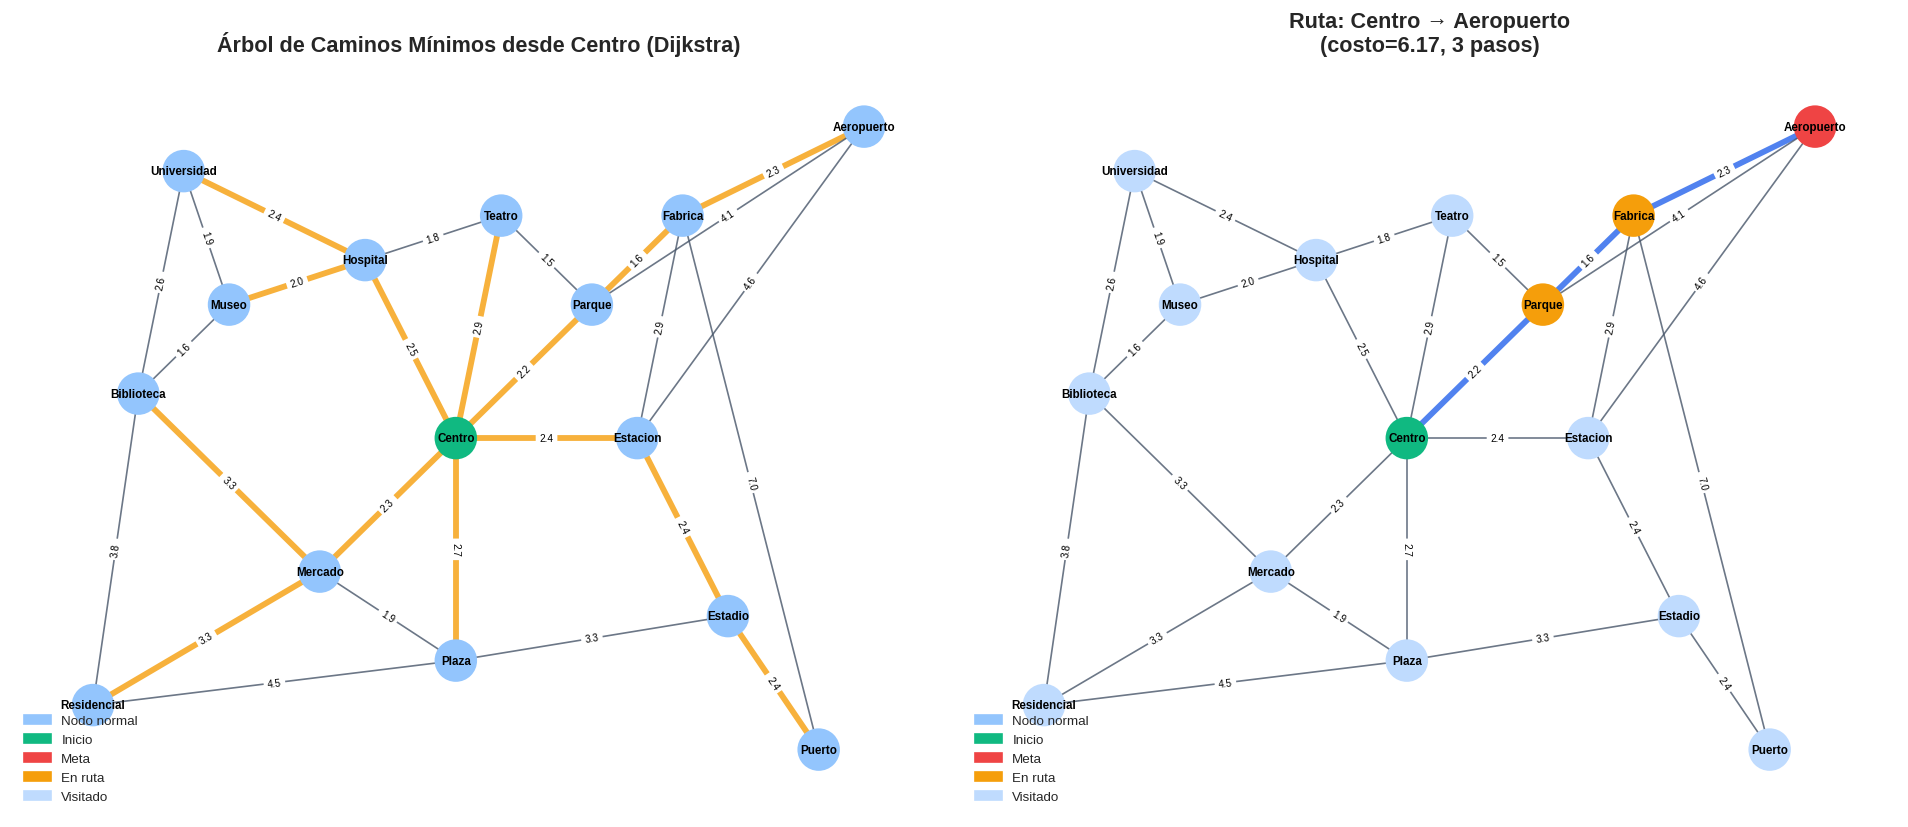

In [7]:
# ── Árbol de caminos mínimos desde el Centro ─────────────────────────────────

# Aristas del árbol de caminos mínimos
aristas_arbol = set()
for nodo, prev in prev_centro.items():
    if prev is not None:
        aristas_arbol.add((prev, nodo))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Izquierda: árbol de caminos mínimos
visualizar_grafo(
    G_ciudad,
    titulo="Árbol de Caminos Mínimos desde Centro (Dijkstra)",
    inicio="Centro",
    aristas_resaltadas=aristas_arbol,
    ax=axes[0]
)

# Derecha: ruta específica Centro → Aeropuerto
ruta_aero = reconstruir_camino(prev_centro, "Centro", "Aeropuerto")
visitados_aero = set(exp_centro)  # Dijkstra expande todos
visualizar_grafo(
    G_ciudad,
    titulo=f"Ruta: Centro → Aeropuerto\n(costo={dist_centro['Aeropuerto']:.2f}, {len(ruta_aero)-1} pasos)",
    nodos_visitados=visitados_aero,
    ruta=ruta_aero,
    inicio="Centro",
    meta="Aeropuerto",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

---
## Sección 3: A* con Heurística de Línea Recta

A* mejora sobre Dijkstra usando una **función de evaluación**:

$$f(n) = g(n) + h(n)$$

donde:
- $g(n)$ = costo acumulado desde el inicio hasta $n$
- $h(n)$ = heurística: estimación del costo de $n$ hasta la meta

Usamos la **distancia euclidiana** como heurística:

$$h(n) = \sqrt{(x_n - x_{meta})^2 + (y_n - y_{meta})^2}$$

Esta heurística es **admisible** porque nunca sobreestima el costo real (la línea recta es el camino más corto posible).

In [8]:
# ── Implementación de A* ──────────────────────────────────────────────────────

def heuristica_euclidiana(nodo, meta):
    """h(n) = distancia euclidiana en línea recta hasta la meta."""
    return dist_euclid(nodo, meta)


def a_star(grafo, inicio, meta, h=heuristica_euclidiana):
    """
    A* desde `inicio` hasta `meta`.

    Retorna:
      camino     : lista de nodos del camino óptimo (o [] si no existe)
      costo      : costo total del camino
      expandidos : lista de nodos expandidos en orden
    """
    # heap: (f, g, nodo)
    heap = [(h(inicio, meta), 0.0, inicio)]
    g_costs = {inicio: 0.0}
    previos = {inicio: None}
    visitados = set()
    expandidos = []

    while heap:
        f, g, nodo = heapq.heappop(heap)

        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos.append(nodo)

        if nodo == meta:
            # Reconstruir camino
            camino = []
            n = meta
            while n is not None:
                camino.append(n)
                n = previos[n]
            camino.reverse()
            return camino, g, expandidos

        for vecino, peso in grafo[nodo].items():
            nuevo_g = g + peso
            if vecino not in g_costs or nuevo_g < g_costs[vecino]:
                g_costs[vecino] = nuevo_g
                previos[vecino] = nodo
                f_nuevo = nuevo_g + h(vecino, meta)
                heapq.heappush(heap, (f_nuevo, nuevo_g, vecino))

    return [], float('inf'), expandidos


# Comparar Dijkstra vs A* en 3 rutas específicas
RUTAS_TEST = [
    ("Centro",      "Aeropuerto"),
    ("Universidad", "Puerto"),
    ("Estadio",     "Museo"),
]

print(f"{'Ruta':<30} {'Algo':<10} {'Costo':>8} {'Expandidos':>12}  Camino")
print("-" * 90)

resultados_comparacion = []

for origen, destino in RUTAS_TEST:
    # Dijkstra
    dist_d, prev_d, exp_d = dijkstra(GRAFO, origen)
    camino_d = reconstruir_camino(prev_d, origen, destino)
    costo_d  = dist_d[destino]
    # Para Dijkstra, contamos nodos hasta que se expande el destino
    exp_d_hasta_meta = exp_d[:exp_d.index(destino) + 1] if destino in exp_d else exp_d

    # A*
    camino_a, costo_a, exp_a = a_star(GRAFO, origen, destino)

    resultados_comparacion.append({
        "ruta":       f"{origen} → {destino}",
        "costo_d":    costo_d,
        "exp_dijkstra": len(exp_d_hasta_meta),
        "costo_a":    costo_a,
        "exp_astar":  len(exp_a),
        "camino":     camino_a,
        "visitados_a": set(exp_a),
    })

    nombre_ruta = f"{origen} → {destino}"
    print(f"{nombre_ruta:<30} {'Dijkstra':<10} {costo_d:>8.2f} {len(exp_d_hasta_meta):>12}  {' → '.join(camino_d)}")
    print(f"{'':<30} {'A*':<10} {costo_a:>8.2f} {len(exp_a):>12}  {' → '.join(camino_a)}")
    print()

Ruta                           Algo          Costo   Expandidos  Camino
------------------------------------------------------------------------------------------
Centro → Aeropuerto            Dijkstra       6.17           14  Centro → Parque → Fabrica → Aeropuerto
                               A*             6.17            4  Centro → Parque → Fabrica → Aeropuerto

Universidad → Puerto           Dijkstra      12.22           15  Universidad → Hospital → Centro → Estacion → Estadio → Puerto
                               A*            12.22           12  Universidad → Hospital → Centro → Estacion → Estadio → Puerto

Estadio → Museo                Dijkstra       9.36           14  Estadio → Estacion → Centro → Hospital → Museo
                               A*             9.36            7  Estadio → Estacion → Centro → Hospital → Museo



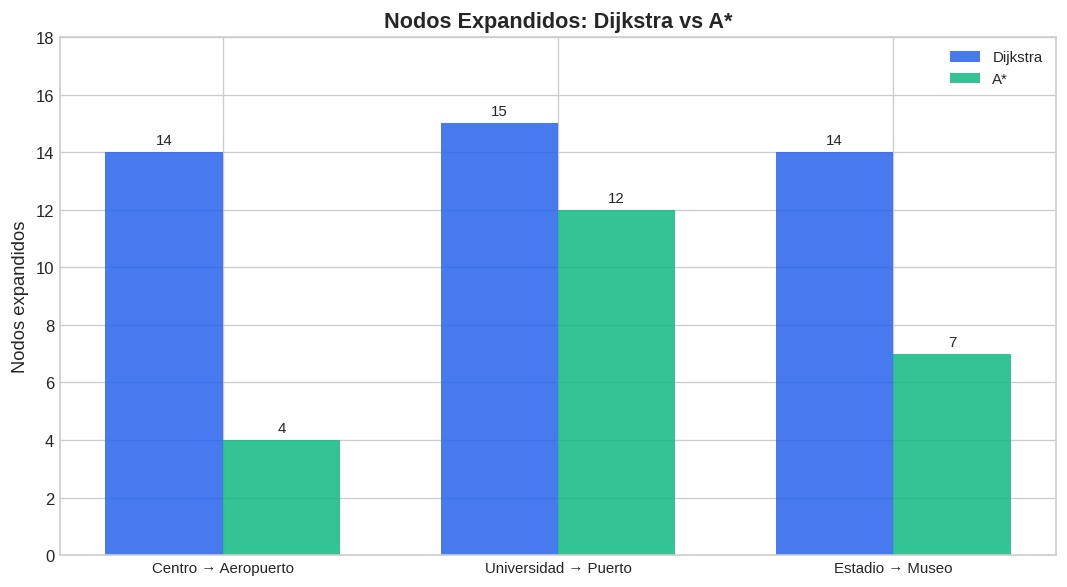

In [9]:
# ── Gráfica comparativa de nodos expandidos ───────────────────────────────────

rutas_labels = [r["ruta"] for r in resultados_comparacion]
exp_dijk = [r["exp_dijkstra"] for r in resultados_comparacion]
exp_ast  = [r["exp_astar"]   for r in resultados_comparacion]

x = np.arange(len(rutas_labels))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_d = ax.bar(x - ancho/2, exp_dijk, ancho, label="Dijkstra",
                   color=COLORS["primary"], alpha=0.85)
barras_a = ax.bar(x + ancho/2, exp_ast,  ancho, label="A*",
                   color=COLORS["secondary"], alpha=0.85)

ax.bar_label(barras_d, padding=3, fontsize=9)
ax.bar_label(barras_a, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(rutas_labels, fontsize=9)
ax.set_ylabel("Nodos expandidos")
ax.set_title("Nodos Expandidos: Dijkstra vs A*", fontweight="bold")
ax.legend()
ax.set_ylim(0, max(exp_dijk + exp_ast) + 3)

plt.tight_layout()
plt.show()

---
## Sección 4: Visualización de Rutas

Visualizamos las tres rutas de prueba mostrando:
- **Nodos explorados** (azul claro): todos los nodos que A* consideró
- **Ruta óptima** (línea azul gruesa): el camino encontrado
- **Inicio** (verde) y **Meta** (rojo)

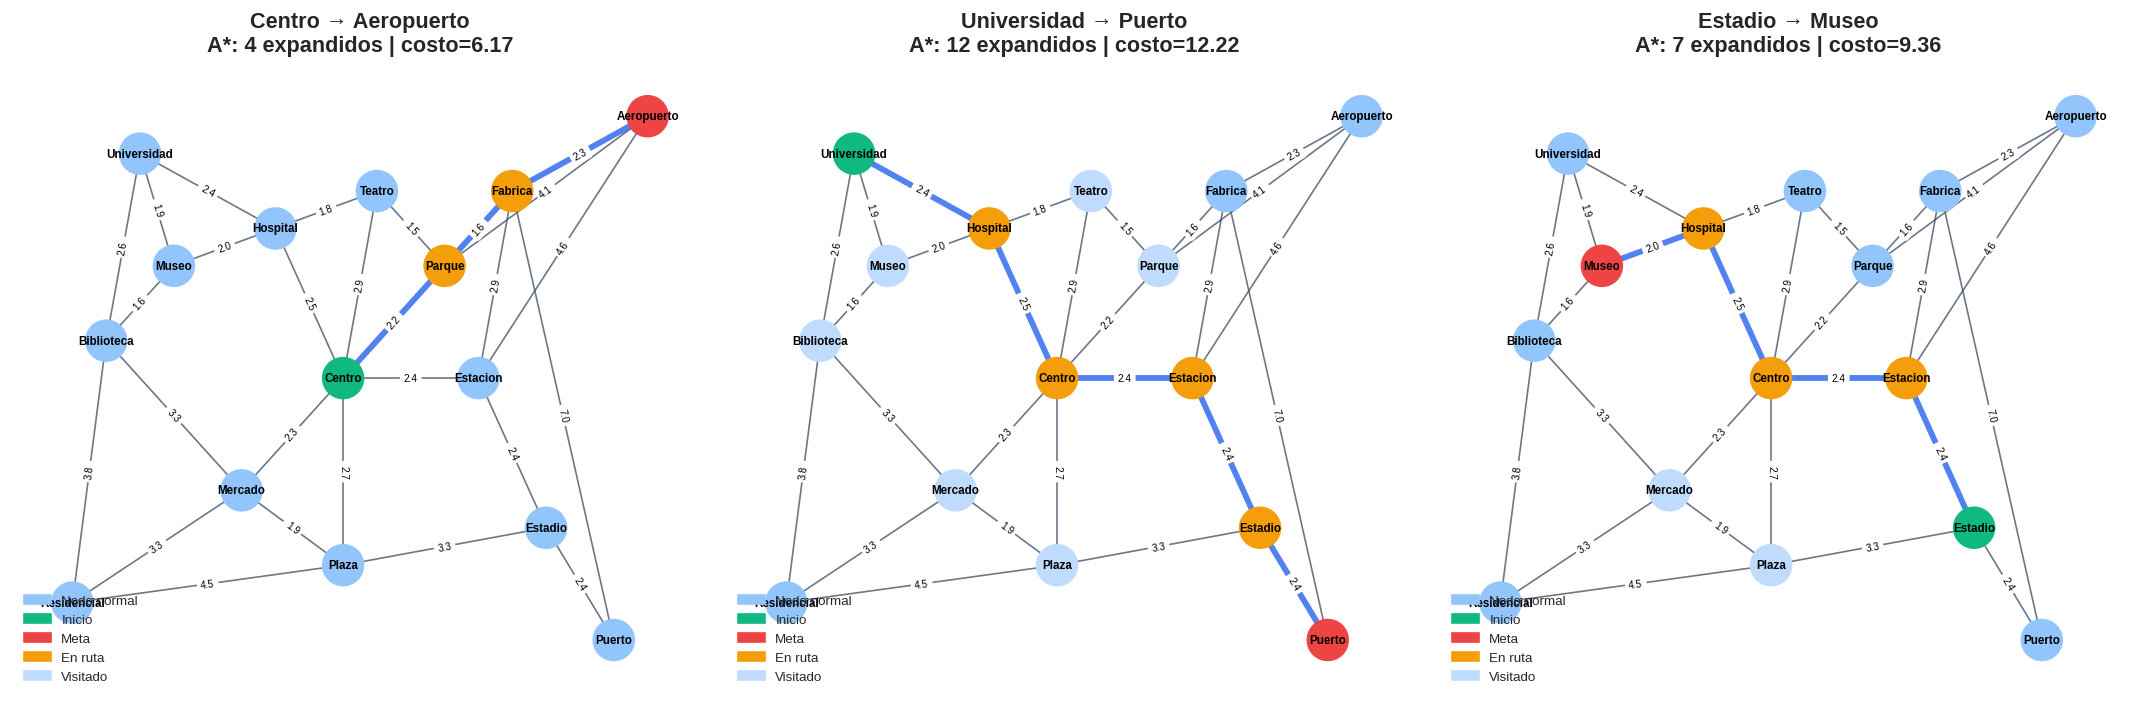

In [10]:
# ── Visualización de las 3 rutas ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, res in enumerate(resultados_comparacion):
    origen, destino = res["ruta"].split(" → ")
    visualizar_grafo(
        G_ciudad,
        titulo=f"{res['ruta']}\nA*: {res['exp_astar']} expandidos | costo={res['costo_a']:.2f}",
        nodos_visitados=res["visitados_a"],
        ruta=res["camino"],
        inicio=origen,
        meta=destino,
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

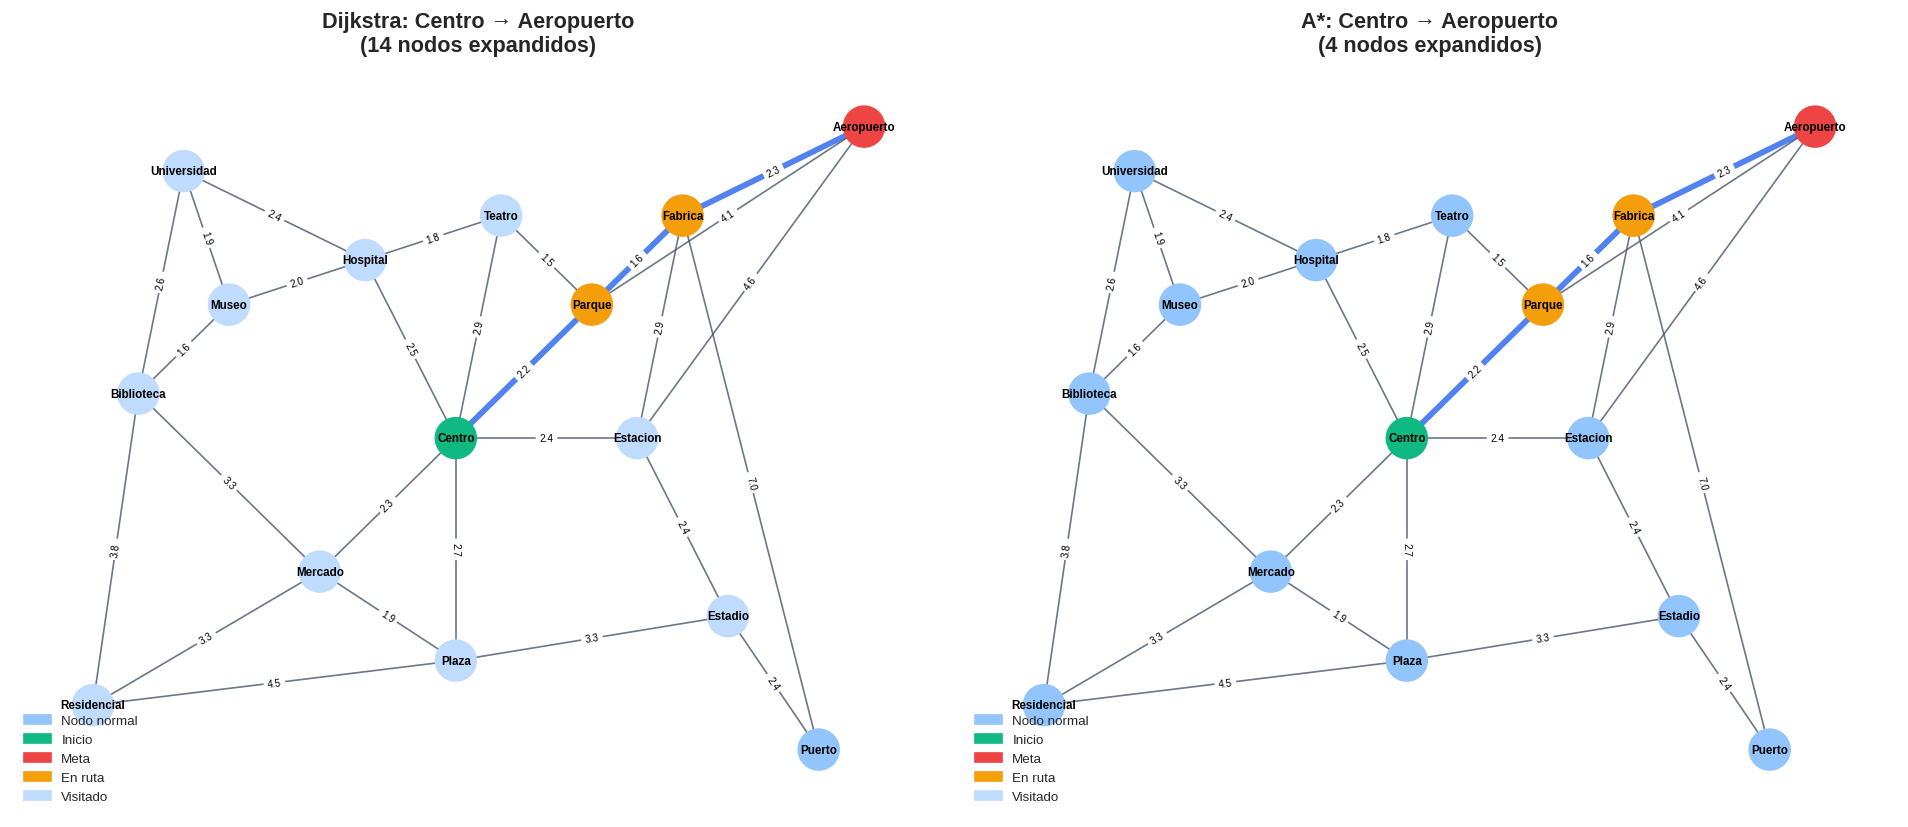

In [11]:
# ── Comparación visual Dijkstra vs A* en Centro → Aeropuerto ─────────────────

origen, destino = "Centro", "Aeropuerto"

# Dijkstra
dist_d, prev_d, exp_d = dijkstra(GRAFO, origen)
camino_d = reconstruir_camino(prev_d, origen, destino)
exp_d_hasta = set(exp_d[:exp_d.index(destino) + 1])

# A*
camino_a, _, exp_a = a_star(GRAFO, origen, destino)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

visualizar_grafo(
    G_ciudad,
    titulo=f"Dijkstra: {origen} → {destino}\n({len(exp_d_hasta)} nodos expandidos)",
    nodos_visitados=exp_d_hasta,
    ruta=camino_d,
    inicio=origen,
    meta=destino,
    ax=axes[0]
)

visualizar_grafo(
    G_ciudad,
    titulo=f"A*: {origen} → {destino}\n({len(exp_a)} nodos expandidos)",
    nodos_visitados=set(exp_a),
    ruta=camino_a,
    inicio=origen,
    meta=destino,
    ax=axes[1]
)

plt.tight_layout()
plt.show()

---
## Ejercicio 1

**Encuentra las 3 rutas más largas entre pares de nodos. ¿En cuáles de estas rutas A\* expande significativamente menos nodos que Dijkstra? ¿Por qué?**

Pistas:
- Itera sobre todos los pares de nodos $(u, v)$ con $u \neq v$.
- Usa A\* para encontrar el costo de cada ruta.
- Ordena de mayor a menor y toma los 3 primeros pares.
- Compara nodos expandidos por A\* y Dijkstra en esos pares.
- Reflexiona: ¿Cómo influye la geometría del grafo en la eficiencia de A\*?

In [12]:
# ── Ejercicio 1 ───────────────────────────────────────────────────────────────
# Tu código aquí

# Paso 1: Encuentra todos los costos de ruta entre pares de nodos
# todos_pares = ...

# Paso 2: Ordena de mayor a menor y toma los 3 más largos
# top3 = ...

# Paso 3: Para cada par, compara nodos expandidos de Dijkstra vs A*
# for origen, destino, costo in top3:
#     ...

# Paso 4: Visualiza las rutas
# ...

---
## Ejercicio 2

**Simula un 'embotellamiento': duplica el peso de 3 aristas que forman una ruta muy usada. Recalcula las rutas más cortas. ¿Qué rutas cambiaron?**

Pistas:
- Identifica las aristas más frecuentes en los caminos óptimos desde el Centro (o en todas las rutas óptimas).
- Duplica los pesos de esas 3 aristas.
- Recalcula Dijkstra desde el Centro.
- Compara las distancias y caminos antes/después del embotellamiento.

In [13]:
# ── Ejercicio 2 ───────────────────────────────────────────────────────────────
# Tu código aquí

# Paso 1: Identifica las aristas más usadas en las rutas óptimas
# contador_aristas = defaultdict(int)
# for nodo in NODOS:
#     camino = reconstruir_camino(prev_centro, "Centro", nodo)
#     ...

# Paso 2: Construye un grafo modificado con pesos duplicados en esas aristas
# ARISTAS_MODIFICADAS = ...
# GRAFO_EMBOTELLADO = ...

# Paso 3: Dijkstra en el grafo modificado
# dist_emb, prev_emb, _ = dijkstra(GRAFO_EMBOTELLADO, "Centro")

# Paso 4: Compara distancias y muestra qué cambió
# ...

# Paso 5 (opcional): Visualiza el grafo con las aristas de embotellamiento marcadas
# ...

---
## Ejercicio 3

**Diseña una heurística alternativa:**

$$h_{manhattan}(n) = 0.5 \times (|x_n - x_{meta}| + |y_n - y_{meta}|)$$

Compara con la heurística euclidiana. ¿Cuál es más **informativa** (más cerca del costo real)? ¿Sigue siendo **admisible**?

Recuerda: una heurística es admisible si $h(n) \leq h^*(n)$ para todo nodo $n$, donde $h^*(n)$ es el costo real hasta la meta.

Pistas:
- Implementa `heuristica_manhattan_escalada(nodo, meta)`.
- Ejecuta A\* con ambas heurísticas en las mismas rutas.
- Compara nodos expandidos: una heurística más informativa → menos nodos expandidos.
- Para verificar admisibilidad, compara $h(n)$ contra el costo real desde $n$ hasta la meta.

In [14]:
# ── Ejercicio 3 ───────────────────────────────────────────────────────────────
# Tu código aquí

# Paso 1: Define la heurística Manhattan escalada
# def heuristica_manhattan_escalada(nodo, meta):
#     ...

# Paso 2: Compara A* con heurística euclidiana vs Manhattan escalada
# para las 3 rutas de prueba: RUTAS_TEST
# print(f"{'Ruta':<30} {'Heurística':<20} {'Expandidos':>12} {'Costo':>8}")
# ...

# Paso 3: Verifica admisibilidad
# Para cada nodo, calcula h_manhattan y compara con el costo real A*
# (usa los resultados de A* como aproximación del costo real h*)
# ...